

# Land Value Tax Analysis for Chicago, Illinois

For this analysis, we're modeling a **Land Value Tax (LVT) shift** for Chicago using Cook County property data.

## Policy Analysis Goals

For this analysis, we're exploring:
- **Revenue-neutral** property tax reform options
- **Split-rate taxation** (different rates for land vs. buildings)
- **Full building abatement** (taxing only land value)
- **Impact on different property types** and neighborhoods
- **Equity implications** across Chicago communities

## Data Source

We're using Cook County's official property assessment data from their ArcGIS MapServer:
- **Dataset**: CookViewer3Parcels 
- **Coverage**: All of Cook County, filtered to Chicago city limits
- **Total Chicago parcels**: ~884,000 properties
- **Data includes**: Assessed values, land values, exemptions, property types, and geometry

Let's begin by importing the necessary libraries and utility functions.


In [1]:
import sys
import pandas as pd
import geopandas as gpd
sys.path.append('..')  # Add parent directory to path
from cloud_utils import (get_feature_data, get_feature_data_with_geometry, get_mapserver_data_with_geometry, 
                        debug_mapserver_structure, get_mapserver_data_with_geometry_filtered, explore_cities_in_dataset,
                        get_mapserver_data_with_resume)
from lvt_utils import model_split_rate_tax, calculate_current_tax, model_full_building_abatement
from census_utils import (get_census_data, get_census_blockgroups_shapefile, get_census_data_with_boundaries, 
                         get_census_blockgroups_from_ftp, get_census_blockgroups_shapefile_chunked, match_to_census_blockgroups)
from datetime import datetime
import pandas as pd
import os

data_scrape = 1

## Step 1: Getting Chicago Property Data

The first step in modeling an LVT shift is obtaining comprehensive property tax data. Cook County provides this through their public ArcGIS MapServer service.

### Cook County GIS Data Source

We're accessing Cook County's **CookViewer3Parcels** dataset which includes:
- **All property parcels** in Cook County (1.8M+ total)
- **Chicago subset**: ~884,000 properties 
- **Comprehensive data**: Assessments, exemptions, property types, and boundaries

### Key Data Elements Available:
- **Assessed Value**: Total property assessment
- **Land Value**: Assessed value of land only  
- **Improvement Value**: Buildings/structures value (calculated)
- **Exemption amounts**: Tax exemptions applied
- **Property characteristics**: Use codes, addresses, neighborhoods
- **Geographic boundaries**: Parcel shapes for mapping

### Data Collection Strategy

Given the large dataset size (884K Chicago records), we'll use a robust approach:
1. **Start with a sample** (50K records) to test the analysis
2. **Expand gradually** once the workflow is validated
3. **Handle connection issues** with retry logic and resumable downloads

Let's begin with the data collection:


In [2]:
# First, let's debug the data structure to understand what we're working with
base_url = "https://gis.cookcountyil.gov/traditional/rest/services"
if data_scrape == 1:
    debug_data = debug_mapserver_structure('CookViewer3Parcels', base_url)


Response keys: ['displayFieldName', 'fieldAliases', 'geometryType', 'spatialReference', 'fields', 'features', 'exceededTransferLimit']
Number of features returned: 5

--- Feature 1 ---
Feature keys: ['attributes', 'geometry']
Attributes keys (first 10): ['OBJECTID', 'GlobalID', 'PARID', 'TAXYR', 'CUR', 'STATUS', 'CITYNAME', 'STATECODE', 'UNITDESC', 'UNITNO']
Geometry keys: ['rings']
Number of rings: 4
First ring has 432 points

--- Feature 2 ---
Feature keys: ['attributes', 'geometry']
Attributes keys (first 10): ['OBJECTID', 'GlobalID', 'PARID', 'TAXYR', 'CUR', 'STATUS', 'CITYNAME', 'STATECODE', 'UNITDESC', 'UNITNO']
Geometry keys: ['rings']
Number of rings: 1
First ring has 9 points

--- Feature 3 ---
Feature keys: ['attributes', 'geometry']
Attributes keys (first 10): ['OBJECTID', 'GlobalID', 'PARID', 'TAXYR', 'CUR', 'STATUS', 'CITYNAME', 'STATECODE', 'UNITDESC', 'UNITNO']
Geometry keys: ['rings']
Number of rings: 1
First ring has 16 points


In [3]:
# ROBUST CHICAGO DATA DOWNLOAD
# This replaces the failed cell above with better error handling

print("🚀 Starting robust Chicago data download...")
print("We know there are 884,109 Chicago records total")
print()

if data_scrape == 1:
    parcel_civic_df = get_mapserver_data_with_resume(
        'CookViewer3Parcels', 
        base_url,
        where_clause="CITYNAME = 'CHICAGO'",   
        start_offset=0,       # Start from beginning
        chunk_delay=0.2      # Half-second delay between chunks
    )

    if parcel_civic_df is not None and len(parcel_civic_df) > 0:
        print(f"✅ SUCCESS! Loaded {len(parcel_civic_df):,} Chicago records")
        print(f"📋 Columns available: {len(parcel_civic_df.columns)}")
        print(f"📍 Geometry data: {'✅ Yes' if 'geometry' in parcel_civic_df.columns else '❌ No'}")
        
        # Quick summary
        if 'CITYNAME' in parcel_civic_df.columns and 'site_city' in parcel_civic_df.columns:
            print(f"🏙️ CITYNAME counts: {parcel_civic_df['CITYNAME'].value_counts().head()}")
        
    else:
        print("❌ Download failed. Let's try a smaller sample...")
        # Fallback: Try even smaller sample
        parcel_civic_df = get_mapserver_data_with_resume(
            'CookViewer3Parcels', 
            base_url,
            where_clause="CITYNAME = 'CHICAGO'",
            start_offset=0,
            chunk_delay=0.2      # Longer delay
        )


🚀 Starting robust Chicago data download...
We know there are 884,109 Chicago records total

Getting count for filter: CITYNAME = 'CHICAGO'
Total records available: 884109
Starting download from offset 0
Fetching records 0 to 2000...
✅ Successfully fetched 2000 records. Total so far: 2000
Fetching records 2000 to 4000...
✅ Successfully fetched 2000 records. Total so far: 4000
Fetching records 4000 to 6000...
✅ Successfully fetched 2000 records. Total so far: 6000
Fetching records 6000 to 8000...
✅ Successfully fetched 2000 records. Total so far: 8000
Fetching records 8000 to 10000...
✅ Successfully fetched 2000 records. Total so far: 10000
Fetching records 10000 to 12000...
✅ Successfully fetched 2000 records. Total so far: 12000
Fetching records 12000 to 14000...
✅ Successfully fetched 2000 records. Total so far: 14000
Fetching records 14000 to 16000...
✅ Successfully fetched 2000 records. Total so far: 16000
Fetching records 16000 to 18000...
✅ Successfully fetched 2000 records. Total

In [4]:


# Create directory if it doesn't exist
data_dir = "data/chicago"
os.makedirs(data_dir, exist_ok=True)

if data_scrape == 1:
    # Save current data with today's date
    today = datetime.now().strftime("%Y-%m-%d")
    
    if parcel_civic_df is not None and len(parcel_civic_df) > 0:
        # Check if data has geometry and convert to GeoDataFrame if needed
        if 'geometry' in parcel_civic_df.columns:
            print("🗺️ Geometry column detected - converting to GeoDataFrame")
            
            # Convert to GeoDataFrame to preserve geometry
            if not isinstance(parcel_civic_df, gpd.GeoDataFrame):
                gdf = gpd.GeoDataFrame(parcel_civic_df, geometry='geometry')
            else:
                gdf = parcel_civic_df
            
            # Save as GeoParquet to preserve geometry
            geoparquet_filename = f"chicago_parcels_with_geometry_{today}.geoparquet"
            geoparquet_filepath = os.path.join(data_dir, geoparquet_filename)
            gdf.to_parquet(geoparquet_filepath, index=False)
            print(f"✅ Data with geometry saved to: {geoparquet_filepath}")
            print(f"📊 Records saved: {len(gdf):,}")
            print(f"🗺️ Geometry type: {gdf.geometry.geom_type.value_counts().to_dict()}")
            
            # Also save as regular parquet (without geometry) for compatibility
            regular_df = gdf.drop(columns=['geometry'])
            filename = f"chicago_parcels_{today}.parquet"
            filepath = os.path.join(data_dir, filename)
            regular_df.to_parquet(filepath, index=False)
            print(f"✅ Data without geometry saved to: {filepath}")
            
        else:
            print("⚠️ No geometry column found - saving as regular parquet")
            filename = f"chicago_parcels_{today}.parquet"
            filepath = os.path.join(data_dir, filename)
            parcel_civic_df.to_parquet(filepath, index=False)
            print(f"✅ Data saved to: {filepath}")
            print(f"📊 Records saved: {len(parcel_civic_df):,}")
        
    else:
        print("❌ No data to save - parcel_civic_df is empty or None")

elif data_scrape == 0:
    # Load the most recent data file with geometry preference
    if os.path.exists(data_dir):
        # First try to find GeoParquet files (with geometry)
        geo_files = [f for f in os.listdir(data_dir) if f.endswith('.geoparquet')]
        regular_files = [f for f in os.listdir(data_dir) if f.endswith('.parquet') and not f.endswith('.geoparquet')]
        
        if geo_files:
            # Prefer GeoParquet files (with geometry)
            geo_files.sort(reverse=True)
            latest_file = geo_files[0]
            filepath = os.path.join(data_dir, latest_file)
            
            print(f"📂 Loading GeoParquet with geometry: {latest_file}")
            parcel_civic_df = gpd.read_parquet(filepath)
            print(f"✅ Loaded {len(parcel_civic_df):,} records with geometry from {latest_file}")
            print(f"🗺️ Geometry column preserved: {'geometry' in parcel_civic_df.columns}")
            if 'geometry' in parcel_civic_df.columns:
                print(f"🗺️ Geometry type: {parcel_civic_df.geometry.geom_type.value_counts().to_dict()}")
            
        elif regular_files:
            # Fall back to regular parquet files
            regular_files.sort(reverse=True)
            latest_file = regular_files[0]
            filepath = os.path.join(data_dir, latest_file)
            
            print(f"📂 Loading regular parquet (no geometry): {latest_file}")
            parcel_civic_df = pd.read_parquet(filepath)
            print(f"✅ Loaded {len(parcel_civic_df):,} records from {latest_file}")
            print("⚠️ No geometry data available in this file")
            
        else:
            print("❌ No parquet files found in data/chicago/")
            print("💡 Set data_scrape = 1 to download new data")
    else:
        print("❌ data/chicago/ directory not found")
        print("💡 Set data_scrape = 1 to create directory and download data")

# Display current data status
if 'parcel_civic_df' in locals() and parcel_civic_df is not None:
    print(f"\n📊 Current dataset: {len(parcel_civic_df):,} records")
    print(f"📋 Columns: {len(parcel_civic_df.columns)}")
    print(f"🗺️ Data type: {type(parcel_civic_df).__name__}")
    if hasattr(parcel_civic_df, 'geometry'):
        print(f"🗺️ Has geometry: Yes")
    else:
        print(f"🗺️ Has geometry: {'geometry' in parcel_civic_df.columns if hasattr(parcel_civic_df, 'columns') else 'No'}")


🗺️ Geometry column detected - converting to GeoDataFrame
✅ Data with geometry saved to: data/chicago/chicago_parcels_with_geometry_2025-06-25.geoparquet
📊 Records saved: 884,109
🗺️ Geometry type: {'Polygon': 884109}
✅ Data without geometry saved to: data/chicago/chicago_parcels_2025-06-25.parquet

📊 Current dataset: 884,109 records
📋 Columns: 72
🗺️ Data type: GeoDataFrame
🗺️ Has geometry: Yes


In [5]:
# Explore the Chicago data structure
if parcel_civic_df is not None and len(parcel_civic_df) > 0:
    print("🎉 CHICAGO DATA LOADED SUCCESSFULLY!")
    print(f"📊 Total records: {len(parcel_civic_df):,}")
    print()
    
    print("📋 Column names in Chicago parcel data:")
    print(parcel_civic_df.columns.tolist())
    print()
    
    # Check data types and structure
    print("🔍 Data structure check:")
    print(f"Data type: {type(parcel_civic_df)}")
    print(f"Is GeoDataFrame: {isinstance(parcel_civic_df, gpd.GeoDataFrame)}")
    print(f"Has geometry: {'geometry' in parcel_civic_df.columns}")
    
    # If it's a GeoDataFrame, show additional geometry info
    if isinstance(parcel_civic_df, gpd.GeoDataFrame) and 'geometry' in parcel_civic_df.columns:
        print(f"CRS (Coordinate Reference System): {parcel_civic_df.crs}")
        print(f"Geometry types: {parcel_civic_df.geometry.geom_type.value_counts().to_dict()}")
        
        # Show bounds
        bounds = parcel_civic_df.total_bounds
        print(f"Spatial bounds: [{bounds[0]:.6f}, {bounds[1]:.6f}, {bounds[2]:.6f}, {bounds[3]:.6f}]")
    print()
    
    # Show sample data
    pd.set_option('display.max_columns', None)
    print("📝 Sample data (first 3 rows):")
    display(parcel_civic_df.head(3))
    
else:
    print("❌ No Chicago data available. Please run the download cell above first.")



🎉 CHICAGO DATA LOADED SUCCESSFULLY!
📊 Total records: 884,109

📋 Column names in Chicago parcel data:
['OBJECTID', 'GlobalID', 'PARID', 'TAXYR', 'CUR', 'STATUS', 'CITYNAME', 'STATECODE', 'UNITDESC', 'UNITNO', 'LOC2', 'ZIP1', 'ZIP2', 'TAXDIST', 'XCOORD', 'YCOORD', 'USER1', 'DEACTIVAT', 'PIN10', 'street_address', 'township_number', 'township_name', 'latitude', 'longitude', 'PIN14_dash', 'Shape.STArea()', 'Shape.STLength()', 'city_state_zip', 'PIN14', 'find_my_dist_link', 'class_info_display', 'assessor_link', 'current_procname', 'current_value_desc', 'LANDSF', 'CURRENTVALUE_TOTAL', 'CURRENTVALUE_LAND', 'CURRENTVALUE_BLDG', 'CURRENTVALUE_HIE_TOT', 'hist_assessval_link', 'BLDGSQFT', 'bldg_const_desc', 'oblique_link', 'historical_photo_link', 'clerk_prop_records_link', 'property_portal_link', 'hist_sf_mf_imp_chars_link', 'BCLASS', 'major_class_description', 'class_description', 'BCONST', 'NBHD', 'BLDGAGE', 'created_date', 'last_edited_date', 'XMin', 'XMax', 'YMin', 'YMax', 'pin', 'neighborho

,OBJECTID,GlobalID,PARID,TAXYR,CUR,STATUS,CITYNAME,STATECODE,UNITDESC,UNITNO,LOC2,ZIP1,ZIP2,TAXDIST,XCOORD,YCOORD,USER1,DEACTIVAT,PIN10,street_address,township_number,township_name,latitude,longitude,PIN14_dash,Shape.STArea(),Shape.STLength(),city_state_zip,PIN14,find_my_dist_link,class_info_display,assessor_link,current_procname,current_value_desc,LANDSF,CURRENTVALUE_TOTAL,CURRENTVALUE_LAND,CURRENTVALUE_BLDG,CURRENTVALUE_HIE_TOT,hist_assessval_link,BLDGSQFT,bldg_const_desc,oblique_link,historical_photo_link,clerk_prop_records_link,property_portal_link,hist_sf_mf_imp_chars_link,BCLASS,major_class_description,class_description,BCONST,NBHD,BLDGAGE,created_date,last_edited_date,XMin,XMax,YMin,YMax,pin,neighborhood_code,board_of_review_district_num,commissioner_district_num,tax_municipality_name,tax_school_elem_dist_name,tax_school_sec_dist_name,tax_school_unified_dist_name,tax_comm_college_dist_name,tax_library_district_name,tax_park_district_name,GlobalID_1,geometry
0,12823,{481C1318-4E27-4CC5-842C-E966D3BA75FF},29012000090000,2024,Y,3.0,CHICAGO,IL,None,None,None,None,None,37026,1.194292e+06,1.811797e+06,37.0,None,2901200009,1 138TH & BISHOP FORD EXPY,37,Thornton,41.638506,-87.564932,29-01-200-009-0000,135268.224135,1953.548885,"CHICAGO, IL",29012000090000,None,RR (Railroad Property),https://www.cookcountyassessor.com/pin/2901200...,CCAOFINAL,2024 Assessor Certified,0.0,NaN,NaN,NaN,NaN,None,NaN,Data unavailable,None,None,None,None,None,RR,Railroad Property,None,NaN,51.0,NaN,NaN,1732569041000,1.193880e+06,1.194660e+06,1.811515e+06,1.812024e+06,29012000090000,37051,3,4,CITY OF CALUMET CITY,SCHOOL DISTRICT 149,THORNTON TOWNSHIP HIGH SCHOOL 205,None,SOUTH SUBURBAN COLLEGE DISTRICT 510,CITY OF CALUMET CITY LIBRARY FUND,CALUMET MEMORIAL PARK DISTRICT,{C1822333-3C6B-4741-B882-B26ED62048B2},"POLYGON ((-87.56589 41.63913, -87.56587 41.639..."
1,12824,{CE5D09CD-1A31-4E16-B3BC-387C0589D7E7},29012000080000,2024,Y,3.0,CHICAGO,IL,None,None,None,None,None,37026,1.194456e+06,1.811985e+06,37.0,None,2901200008,1 138TH & BISHOP FORD EXPY,37,Thornton,41.639016,-87.564323,29-01-200-008-0000,123337.367614,1620.550543,"CHICAGO, IL",29012000080000,None,517 (Commercial/Industrial),https://www.cookcountyassessor.com/pin/2901200...,CCAOFINAL,2024 Assessor Certified,105110.0,98773.0,78833.0,19940.0,NaN,None,NaN,Data unavailable,None,None,None,None,None,517,Commercial/Industrial,None,NaN,51.0,83.0,NaN,1736290249000,1.194171e+06,1.194637e+06,1.811702e+06,1.812279e+06,29012000080000,37051,3,4,CITY OF CALUMET CITY,SCHOOL DISTRICT 149,THORNTON TOWNSHIP HIGH SCHOOL 205,None,SOUTH SUBURBAN COLLEGE DISTRICT 510,CITY OF CALUMET CITY LIBRARY FUND,CALUMET MEMORIAL PARK DISTRICT,{70DE6421-3763-4381-80AF-9B17707A9AD2},"POLYGON ((-87.56391 41.63975, -87.56391 41.639..."
2,12825,{88A5F4DA-7F15-4C3B-AF72-73BE0561E433},29012000060000,2024,Y,3.0,CHICAGO,IL,None,None,None,None,None,37026,1.193342e+06,1.811371e+06,37.0,None,2901200006,1 138TH & BISHOP FORD EXPY,37,Thornton,41.637360,-87.568420,29-01-200-006-0000,27992.553466,747.627262,"CHICAGO, IL",29012000060000,None,100 (Vacant),https://www.cookcountyassessor.com/pin/2901200...,CCAOFINAL,2024 Assessor Certified,23522.0,7057.0,7057.0,0.0,NaN,None,NaN,Data unavailable,None,None,None,None,None,100,Vacant,None,NaN,51.0,NaN,NaN,1732569041000,1.193223e+06,1.193466e+06,1.811308e+06,1.811451e+06,29012000060000,37051,3,4,CITY OF CALUMET CITY,SCHOOL DISTRICT 149,THORNTON TOWNSHIP HIGH SCHOOL 205,None,SOUTH SUBURBAN COLLEGE DISTRICT 510,CITY OF CALUMET CITY LIBRARY FUND,CALUMET MEMORIAL PARK DISTRICT,{0D80863E-2A2F-4CB9-AEAD-43482ED4E967},"POLYGON ((-87.56882 41.63757, -87.56879 41.637..."


In [6]:
# Display first two rows where CURRENTVALUE_HIE_TOT is not NaN
if 'CURRENTVALUE_HIE_TOT' in parcel_civic_df.columns:
    # Filter for non-NaN HIE values
    hie_not_nan = parcel_civic_df[parcel_civic_df['CURRENTVALUE_HIE_TOT'].notna()]
    
    if len(hie_not_nan) > 0:
        print("🔍 First two rows where CURRENTVALUE_HIE_TOT is not NaN:")
        display(hie_not_nan.head(2))
        
        # Print first two assessor_link URLs in full
        if 'assessor_link' in hie_not_nan.columns:
            print("\n🔗 First two assessor_link URLs (where HIE_TOT is not NaN):")
            for i in range(min(2, len(hie_not_nan))):
                print(f"Record {i+1}: {hie_not_nan.iloc[i]['assessor_link']}")
                print()
        else:
            print("❌ 'assessor_link' column not found in dataset")
    else:
        print("❌ No records found where CURRENTVALUE_HIE_TOT is not NaN")
else:
    print("❌ 'CURRENTVALUE_HIE_TOT' column not found in dataset")
    print("📋 Available columns:")
    print(parcel_civic_df.columns.tolist())


🔍 First two rows where CURRENTVALUE_HIE_TOT is not NaN:


,OBJECTID,GlobalID,PARID,TAXYR,CUR,STATUS,CITYNAME,STATECODE,UNITDESC,UNITNO,LOC2,ZIP1,ZIP2,TAXDIST,XCOORD,YCOORD,USER1,DEACTIVAT,PIN10,street_address,township_number,township_name,latitude,longitude,PIN14_dash,Shape.STArea(),Shape.STLength(),city_state_zip,PIN14,find_my_dist_link,class_info_display,assessor_link,current_procname,current_value_desc,LANDSF,CURRENTVALUE_TOTAL,CURRENTVALUE_LAND,CURRENTVALUE_BLDG,CURRENTVALUE_HIE_TOT,hist_assessval_link,BLDGSQFT,bldg_const_desc,oblique_link,historical_photo_link,clerk_prop_records_link,property_portal_link,hist_sf_mf_imp_chars_link,BCLASS,major_class_description,class_description,BCONST,NBHD,BLDGAGE,created_date,last_edited_date,XMin,XMax,YMin,YMax,pin,neighborhood_code,board_of_review_district_num,commissioner_district_num,tax_municipality_name,tax_school_elem_dist_name,tax_school_sec_dist_name,tax_school_unified_dist_name,tax_comm_college_dist_name,tax_library_district_name,tax_park_district_name,GlobalID_1,geometry
214,179387,{E5956978-49B4-48A2-81CA-6238EF7F77AB},26323040110000,2024,Y,3.0,CHICAGO,IL,None,None,None,60633,1532,70002,1.201337e+06,1.815951e+06,70.0,None,2632304011,13506 S AVENUE N,70,Hyde Park,41.649728,-87.539021,26-32-304-011-0000,3748.706463,310.030632,"CHICAGO, IL 60633",26323040110000,None,205 (Residential),https://www.cookcountyassessor.com/pin/2632304...,CCAOFINAL,2024 Assessor Certified,3751.0,20600.0,1500.0,19100.0,1604.0,None,2186.0,Frame,None,None,None,None,None,205,Residential,None,1.0,280.0,113.0,NaN,1736284473000,1.201274e+06,1.201399e+06,1.815935e+06,1.815966e+06,26323040110000,70280,3,4,CITY OF CHICAGO,None,None,BOARD OF EDUCATION,CHICAGO COMMUNITY COLLEGE DISTRICT 508,CITY OF CHICAGO LIBRARY FUND,CHICAGO PARK DISTRICT,{2750FBDC-B1BC-4793-9251-83ECDA744AAE},"POLYGON ((-87.53879 41.64968, -87.53924 41.649..."
418,179998,{6B73CC5C-B029-4B4A-84AA-B0008C2CF5B3},26323040100000,2024,Y,3.0,CHICAGO,IL,None,None,None,60633,1532,70002,1.201336e+06,1.815981e+06,70.0,None,2632304010,13504 S AVENUE N,70,Hyde Park,41.649811,-87.539021,26-32-304-010-0000,3750.627518,310.031058,"CHICAGO, IL 60633",26323040100000,None,205 (Residential),https://www.cookcountyassessor.com/pin/2632304...,CCAOFINAL,2024 Assessor Certified,3751.0,25100.0,1500.0,23600.0,7500.0,None,2071.0,Frame,None,None,None,None,None,205,Residential,None,1.0,280.0,132.0,NaN,1736284473000,1.201274e+06,1.201399e+06,1.815965e+06,1.815996e+06,26323040100000,70280,3,4,CITY OF CHICAGO,None,None,BOARD OF EDUCATION,CHICAGO COMMUNITY COLLEGE DISTRICT 508,CITY OF CHICAGO LIBRARY FUND,CHICAGO PARK DISTRICT,{16A017A9-7769-40F6-B301-1A096B841CFC},"POLYGON ((-87.53879 41.64976, -87.53924 41.649..."



🔗 First two assessor_link URLs (where HIE_TOT is not NaN):
Record 1: https://www.cookcountyassessor.com/pin/26323040110000

Record 2: https://www.cookcountyassessor.com/pin/26323040100000



In [7]:
# Check for duplicate PIN14 values
if 'PIN14' in parcel_civic_df.columns:
    duplicate_count = parcel_civic_df['PIN14'].duplicated().sum()
    print(f"🔍 Number of duplicate PIN14 values: {duplicate_count:,}")
    
    if duplicate_count > 0:
        print(f"📊 Total records: {len(parcel_civic_df):,}")
        print(f"📈 Duplicate percentage: {(duplicate_count / len(parcel_civic_df) * 100):.2f}%")
        
        # Show some examples of duplicate PIN14s
        duplicates = parcel_civic_df[parcel_civic_df['PIN14'].duplicated(keep=False)]
        print(f"\n🔍 Sample of duplicate PIN14s (first 5):")
        duplicate_ids = duplicates['PIN14'].value_counts().head()
        for pin_id, count in duplicate_ids.items():
            print(f"   PIN14 {pin_id}: {count} occurrences")
    else:
        print("✅ No duplicate PIN14 values found")
else:
    print("❌ 'PIN14' column not found in dataset")


🔍 Number of duplicate PIN14 values: 0
✅ No duplicate PIN14 values found


In [8]:
# Print value counts for class_description and major_class_description
print("🔍 Value counts for class_description:")
if 'class_description' in parcel_civic_df.columns:
    print(parcel_civic_df['class_description'].value_counts())
else:
    print("❌ 'class_description' column not found")
print()

print("🔍 Value counts for major_class_description:")
if 'major_class_description' in parcel_civic_df.columns:
    print(parcel_civic_df['major_class_description'].value_counts())
else:
    print("❌ 'major_class_description' column not found")
print()


🔍 Value counts for class_description:
Series([], Name: count, dtype: int64)

🔍 Value counts for major_class_description:
major_class_description
Residential                                               734825
Exempt Property                                            49749
Commercial/Industrial                                      48579
Vacant                                                     32879
Multi-Family                                               13608
Railroad Property                                           2776
Class 3 Multi-Family Residential Real Estate Incentive       778
Industrial Incentive                                         389
Commercial Incentive                                         215
Not-For-Profit                                               204
Commercial/Industrial Remediation Incentive                   94
Commercial/Industrial Incentive                                2
Name: count, dtype: int64



In [9]:
# Explore different value columns that might contribute to total assessed value
# First exclude exempt properties
if 'major_class_description' in parcel_civic_df.columns:
    df_filtered = parcel_civic_df[parcel_civic_df['major_class_description'] != 'Exempt Property'].copy()
    print(f"🔍 Filtered out exempt properties: {len(parcel_civic_df) - len(df_filtered):,} exempt properties excluded")
    print(f"📊 Analyzing {len(df_filtered):,} non-exempt properties")
    print()
else:
    df_filtered = parcel_civic_df.copy()
    print("⚠️ 'major_class_description' column not found, analyzing all properties")
    print()

value_columns = ['CURRENTVALUE_TOTAL', 'CURRENTVALUE_LAND', 'CURRENTVALUE_BLDG', 'CURRENTVALUE_HIE_TOT']

print("🔍 Exploring value columns in Chicago parcel data (excluding exempt properties):")
print()

for col in value_columns:
    if col in df_filtered.columns:
        total_val = df_filtered[col].sum()
        mean_val = df_filtered[col].mean()
        median_val = df_filtered[col].median()
        non_zero_count = (df_filtered[col] > 0).sum()
        
        print(f"📊 {col}:")
        print(f"   💰 Total: ${total_val:,.2f}")
        print(f"   📈 Average: ${mean_val:,.2f}")
        print(f"   📉 Median: ${median_val:,.2f}")
        print(f"   🔢 Non-zero records: {non_zero_count:,} / {len(df_filtered):,}")
        print()

# Check if values sum up correctly
if all(col in df_filtered.columns for col in ['CURRENTVALUE_LAND', 'CURRENTVALUE_BLDG', 'CURRENTVALUE_HIE_TOT']):
    calculated_total = (df_filtered['CURRENTVALUE_LAND'] + 
                       df_filtered['CURRENTVALUE_BLDG'] + 
                       df_filtered['CURRENTVALUE_HIE_TOT'])
    
    print("🔍 Checking if components sum to total:")
    print(f"   Land + Building + HIE Total: ${calculated_total.sum():,.2f}")
    print(f"   CURRENTVALUE_TOTAL: ${df_filtered['CURRENTVALUE_TOTAL'].sum():,.2f}")
    print(f"   Difference: ${abs(calculated_total.sum() - df_filtered['CURRENTVALUE_TOTAL'].sum()):,.2f}")
    print()

# Show sample breakdown for first few records
print("📝 Sample value breakdown (first 5 records, excluding exempt properties):")
sample_cols = ['CURRENTVALUE_TOTAL', 'CURRENTVALUE_LAND', 'CURRENTVALUE_BLDG', 'CURRENTVALUE_HIE_TOT']
if all(col in df_filtered.columns for col in sample_cols):
    display(df_filtered[sample_cols].head())
else:
    print("❌ Some value columns not found in dataset")
    print("📋 Available columns:")
    print(df_filtered.columns.tolist())


🔍 Filtered out exempt properties: 49,749 exempt properties excluded
📊 Analyzing 834,360 non-exempt properties

🔍 Exploring value columns in Chicago parcel data (excluding exempt properties):

📊 CURRENTVALUE_TOTAL:
   💰 Total: $50,532,514,431.00
   📈 Average: $60,768.77
   📉 Median: $26,000.00
   🔢 Non-zero records: 831,554 / 834,360

📊 CURRENTVALUE_LAND:
   💰 Total: $11,166,266,087.00
   📈 Average: $13,428.19
   📉 Median: $4,500.00
   🔢 Non-zero records: 830,580 / 834,360

📊 CURRENTVALUE_BLDG:
   💰 Total: $39,366,248,344.00
   📈 Average: $47,340.58
   📉 Median: $19,797.00
   🔢 Non-zero records: 791,465 / 834,360

📊 CURRENTVALUE_HIE_TOT:
   💰 Total: $14,575,767.00
   📈 Average: $3,996.65
   📉 Median: $2,400.00
   🔢 Non-zero records: 3,647 / 834,360

🔍 Checking if components sum to total:
   Land + Building + HIE Total: $200,318,804.00
   CURRENTVALUE_TOTAL: $50,532,514,431.00
   Difference: $50,332,195,627.00

📝 Sample value breakdown (first 5 records, excluding exempt properties):


,CURRENTVALUE_TOTAL,CURRENTVALUE_LAND,CURRENTVALUE_BLDG,CURRENTVALUE_HIE_TOT
0,NaN,NaN,NaN,NaN
1,98773.0,78833.0,19940.0,NaN
2,7057.0,7057.0,0.0,NaN
3,29619.0,29619.0,0.0,NaN
4,NaN,NaN,NaN,NaN


In [10]:
# Working with Geometry Data
if isinstance(parcel_civic_df, gpd.GeoDataFrame) and 'geometry' in parcel_civic_df.columns:
    print("🗺️ GEOMETRY DATA ANALYSIS")
    print("=" * 40)
    
    # Basic geometry statistics
    print(f"📊 Total parcels with geometry: {(~parcel_civic_df.geometry.isna()).sum():,}")
    print(f"📊 Parcels without geometry: {parcel_civic_df.geometry.isna().sum():,}")
    print()
    
    # Geometry type breakdown
    geom_types = parcel_civic_df.geometry.geom_type.value_counts()
    print("🔍 Geometry types breakdown:")
    for geom_type, count in geom_types.items():
        percentage = (count / len(parcel_civic_df)) * 100
        print(f"   {geom_type}: {count:,} ({percentage:.2f}%)")
    print()
    
    # Calculate areas for valid polygons
    valid_geom = parcel_civic_df[~parcel_civic_df.geometry.isna()]
    if len(valid_geom) > 0:
        # Calculate area in square feet (assuming data is in appropriate projection)
        valid_geom = valid_geom.copy()
        valid_geom['area_sqft'] = valid_geom.geometry.area
        
        print("📏 Parcel area statistics (square feet):")
        print(f"   Minimum area: {valid_geom['area_sqft'].min():,.2f} sq ft")
        print(f"   Maximum area: {valid_geom['area_sqft'].max():,.2f} sq ft")
        print(f"   Mean area: {valid_geom['area_sqft'].mean():,.2f} sq ft")
        print(f"   Median area: {valid_geom['area_sqft'].median():,.2f} sq ft")
        print()
        
        # Show relationship between LANDSF and calculated area
        if 'LANDSF' in valid_geom.columns:
            landsf_available = (~valid_geom['LANDSF'].isna()).sum()
            print(f"🔍 LANDSF field comparison (available for {landsf_available:,} parcels):")
            
            # Compare for parcels that have both
            comparison_data = valid_geom[~valid_geom['LANDSF'].isna()].copy()
            if len(comparison_data) > 0:
                comparison_data['area_difference'] = abs(comparison_data['area_sqft'] - comparison_data['LANDSF'])
                comparison_data['area_ratio'] = comparison_data['area_sqft'] / comparison_data['LANDSF']
                
                print(f"   Mean difference: {comparison_data['area_difference'].mean():,.2f} sq ft")
                print(f"   Median ratio (calculated/LANDSF): {comparison_data['area_ratio'].median():.4f}")
                print(f"   Areas within 10% match: {(abs(comparison_data['area_ratio'] - 1) < 0.1).sum():,} parcels")
    
    print()
    print("✅ Geometry data is properly preserved and accessible for spatial analysis!")
    print("✅ Data can now be used for mapping, spatial joins, and GIS operations!")
    
else:
    print("⚠️ No geometry data available in the current dataset")
    print("💡 To get geometry data, set data_scrape = 1 and use the download function that includes geometry")


🗺️ GEOMETRY DATA ANALYSIS
📊 Total parcels with geometry: 884,109
📊 Parcels without geometry: 0

🔍 Geometry types breakdown:
   Polygon: 884,109 (100.00%)



/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_36606/3524670939.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  valid_geom['area_sqft'] = valid_geom.geometry.area


📏 Parcel area statistics (square feet):
   Minimum area: 0.00 sq ft
   Maximum area: 0.00 sq ft
   Mean area: 0.00 sq ft
   Median area: 0.00 sq ft

🔍 LANDSF field comparison (available for 884,108 parcels):
   Mean difference: 24,832.88 sq ft
   Median ratio (calculated/LANDSF): 0.0000
   Areas within 10% match: 0 parcels

✅ Geometry data is properly preserved and accessible for spatial analysis!
✅ Data can now be used for mapping, spatial joins, and GIS operations!


## Step 3: Recreating Current Property Tax Revenue

Before we can model an LVT shift, we need to accurately recreate the current property tax system. This validation step ensures our dataset correctly reflects the real-world tax landscape.


In [11]:

parcel_civic_df['CURRENTVALUE_TOTAL'] = parcel_civic_df['CURRENTVALUE_TOTAL'] * 3.0


millage_rate = 	1.612
df = parcel_civic_df
df['millage_rate'] = millage_rate

current_revenue, second_revenue,df = calculate_current_tax(
    df=df, 
    tax_value_col='CURRENTVALUE_TOTAL',
    millage_rate_col='millage_rate'
)


print(f"Total number of properties: {len(df):,}")
print(f"Current annual revenue with ${millage_rate*1000}/1000 millage rate: ${current_revenue:,.2f}")



Total current tax revenue: $244,425,550.92
Total number of properties: 884,109
Current annual revenue with $1612.0/1000 millage rate: $244,425,550.92


## Step 4: Modeling the Split-Rate Land Value Tax

Now for the exciting part - modeling the LVT shift! We'll create a revenue-neutral policy that taxes land at 4 times the rate of buildings.

### The Split-Rate Formula

Under our proposed system:
- **Buildings** are taxed at a lower rate (Building Millage)  
- **Land** is taxed at 4x that rate (4 × Building Millage)
- **Total revenue** remains the same as current system

The formula to solve for the building millage rate is:
```
Current Revenue = (Building Millage × Total Taxable Buildings) + (4 × Building Millage × Total Taxable Land)
```

### Handling Exemptions in Split-Rate System

Since we want to maintain existing exemptions, we need to:
1. Apply exemptions to building value first
2. If exemptions exceed building value, apply remainder to land value
3. Calculate separate taxable values for land and buildings

This ensures properties don't over-benefit from exemptions and maintains the intent of existing tax policy.


In [12]:

# Calculate improvement value as assessed amount minus land value
# Multiply land and building values by 3
df['CURRENTVALUE_LAND'] = df['CURRENTVALUE_LAND'] * 3
df['CURRENTVALUE_BLDG'] = df['CURRENTVALUE_BLDG'] * 3

# 100% building abatement (full building exemption)
land_millage, improvement_millage, revenue, df_result = model_split_rate_tax(
df, 'CURRENTVALUE_LAND', 'CURRENTVALUE_BLDG', current_revenue=current_revenue, land_improvement_ratio=4.0
)

# The function returns the updated dataframe with new tax calculations
# Use the returned dataframe which contains the calculated tax changes
df = df_result.copy()

# The function already calculates and adds these columns to the result dataframe:
# - 'new_tax': The new tax amount under the building abatement system
# - 'tax_change': Difference between new and current tax
# - 'tax_change_pct': Percentage change in tax
# - 'taxable_value': The taxable value after abatement
# - 'tax_capped': Flag indicating if tax was capped (if percentage_cap_col was provided)


Split-rate tax model (Land:Improvement = 4.0:1)
Land millage rate: 3.8776
Improvement millage rate: 0.9694
Total tax revenue: $244,425,550.92
Target revenue: $244,425,550.92
Revenue difference: $0.00 (0.0000%)


## Step 5: Understanding Property Types and Impacts

With our split-rate tax calculated, we can now analyze which property types are most affected. Understanding the distribution of tax impacts across different property categories is crucial for policy makers and stakeholders.

### Property Type Analysis

We'll examine how the tax burden shifts across:
- **Residential properties** (single-family, multi-family, condos)
- **Commercial properties** (retail, office, industrial)  
- **Vacant land** (often sees largest increases under LVT)
- **Exempt properties** (government, religious, charitable)

### Key Metrics to Track:
- **Count**: Number of properties in each category
- **Median tax change**: Typical impact (less affected by outliers)
- **Average percentage change**: Overall magnitude of impact
- **Percentage with increases**: How many properties see tax increases

This analysis helps identify which sectors benefit from the LVT shift (typically developed properties) and which see increased burden (typically land-intensive properties with low improvement ratios).


In [13]:
# Print counts of prop_use_desc
print("Property Use Description Counts:")
print(df['major_class_description'].value_counts())
print(f"\nTotal unique property use descriptions: {df['major_class_description'].nunique()}")


Property Use Description Counts:
major_class_description
Residential                                               734825
Exempt Property                                            49749
Commercial/Industrial                                      48579
Vacant                                                     32879
Multi-Family                                               13608
Railroad Property                                           2776
Class 3 Multi-Family Residential Real Estate Incentive       778
Industrial Incentive                                         389
Commercial Incentive                                         215
Not-For-Profit                                               204
Commercial/Industrial Remediation Incentive                   94
Commercial/Industrial Incentive                                2
Name: count, dtype: int64

Total unique property use descriptions: 12


In [14]:
# For each column, show top 10 most common values and their counts
columns_to_analyze = ['NBHD', 'major_class_description']

for col in columns_to_analyze:
    print(f"\nTop 10 values for {col}:")
    value_counts = df[col].value_counts().head(10)
    print(value_counts)
    print(f"Total unique values: {df[col].nunique()}")
    print("-" * 50)

# Let's also look at some basic statistics about these groups
print("\nMedian tax changes by various groupings:")

for col in columns_to_analyze:
    print(f"\nMedian tax change by {col}:")
    median_changes = df.groupby(col)['tax_change'].agg([
        'count',
        'median',
        lambda x: (x > 0).mean() * 100  # Percentage with increase
    ]).round(2)
    median_changes.columns = ['Count', 'Median Change ($)', '% With Increase']
    print(median_changes.sort_values('Count', ascending=False).head(10))


Top 10 values for NBHD:
NBHD
30.0     79635
10.0     41126
120.0    30210
70.0     28628
22.0     27971
11.0     26927
60.0     25599
131.0    25233
12.0     24026
150.0    22955
Name: count, dtype: int64
Total unique values: 119
--------------------------------------------------

Top 10 values for major_class_description:
major_class_description
Residential                                               734825
Exempt Property                                            49749
Commercial/Industrial                                      48579
Vacant                                                     32879
Multi-Family                                               13608
Railroad Property                                           2776
Class 3 Multi-Family Residential Real Estate Incentive       778
Industrial Incentive                                         389
Commercial Incentive                                         215
Not-For-Profit                                               204


### Creating Detailed Property Categories

To better understand impacts, we'll create a detailed property categorization system that groups similar property types together. This makes the analysis more meaningful and interpretable.

The function below categorizes properties into groups like:
- **Single Family** (with subcategories by lot size)
- **Multi-Family** (small vs. large)
- **Commercial** (by type: retail, office, industrial)
- **Exempt** (by type: government, religious, charitable)

This categorization helps us understand not just that "residential" properties are affected, but specifically which types of residential properties see the biggest changes.


In [15]:
# Create a summary DataFrame grouped by PROPTYPE
proptype_analysis = df.groupby('major_class_description').agg({
    'tax_change_pct': ['mean', 'median'],  # Average and median percentage change
    'tax_change': 'median',    # Median dollar change
    'PARID': 'count'        # Count of properties
}).round(2)

# Flatten column names
proptype_analysis.columns = [
    'Avg_Pct_Change',
    'Median_Pct_Change', 
    'Median_Dollar_Change',
    'Property_Count'
]

# Add percentage that increase
proptype_increases = df.groupby('major_class_description').agg({
    'tax_change': lambda x: (x > 0).mean() * 100  # Percentage with increase
}).round(2)

proptype_analysis['Percent_Increased'] = proptype_increases['tax_change']

# Sort by count of properties (descending)
proptype_analysis = proptype_analysis.sort_values('Property_Count', ascending=False)

# Print results
print("Analysis by Property Type:\n")
print("Note: All monetary values in dollars, percentages shown as %\n")
print(proptype_analysis.to_string())

# Print some summary statistics
print("\nOverall Summary:")
print(f"Total properties analyzed: {proptype_analysis['Property_Count'].sum():,}")
print(f"Overall median dollar change: ${df['tax_change'].median():,.2f}")
print(f"Overall average percent change: {df['tax_change_pct'].mean():.2f}%")
print(f"Overall median percent change: {df['tax_change_pct'].median():.2f}%")
print(f"Overall percent of properties with increase: {(df['tax_change'] > 0).mean()*100:.2f}%")

Analysis by Property Type:

Note: All monetary values in dollars, percentages shown as %

                                                        Avg_Pct_Change  Median_Pct_Change  Median_Dollar_Change  Property_Count  Percent_Increased
major_class_description                                                                                                                           
Residential                                                       1.11              -5.52                 -3.49          734825              41.55
Exempt Property                                                   0.25               0.00                  0.00           49749               0.24
Commercial/Industrial                                            51.62              36.77                 64.95           48579              72.41
Vacant                                                          140.09             140.54                 19.12           32879              99.91
Multi-Family                

### Summary of Tax Impacts by Property Category

Now we can see the clear patterns of how different property types are affected by the LVT shift. This table will show us:

- **Which property types benefit** (negative changes = tax decreases)
- **Which property types pay more** (positive changes = tax increases)  
- **How concentrated the impacts are** (median vs. average differences)
- **What percentage of each type sees increases**

Generally, we expect:
- **Developed properties** (houses, commercial buildings) to see tax **decreases**
- **Vacant land** to see the **largest increases** 
- **Properties with high improvement-to-land ratios** to benefit most


## Step 6: Adding Geographic Context

To make our analysis spatially-aware, we need to add geographic boundaries to our parcel data. This enables us to:

- **Create maps** showing tax changes across the city
- **Analyze patterns by neighborhood** or district  
- **Combine with demographic data** for equity analysis
- **Present results visually** to stakeholders

We'll fetch the parcel boundary data from the same ArcGIS service that contains the geometric information for each property.


### Merging Tax Analysis with Geographic Data

Here we combine our tax analysis results with the geographic boundaries. This creates a spatially-enabled dataset that allows us to:

1. **Map tax changes** across South Bend
2. **Identify spatial patterns** in tax impacts
3. **Prepare for demographic analysis** by having geographic context

The merge should give us the same number of records as our original analysis, now with geographic coordinates for each parcel.


In [16]:
import geopandas as gpd
from shapely import wkb



In [17]:
census_data, census_boundaries = get_census_data_with_boundaries(
    fips_code='17031',  # Illinois (17) + Cook County (031)
    year=2021,
    api_key='e22bb2247fdb11c140fc8aa531e952a1e11539b7'  # Replace with your actual Census API key
)
print("Grabbed")

🔧 Using chunked approach for large county 17031
🔍 Getting census tracts for county 17031...
📋 Found 4002 census tracts
✅ Tract 010100 (1/4002): 27 block groups
✅ Tract 010100 (2/4002): 27 block groups
✅ Tract 010100 (3/4002): 27 block groups
✅ Tract 010201 (4/4002): 53 block groups
✅ Tract 010201 (5/4002): 53 block groups
✅ Tract 010201 (6/4002): 53 block groups
✅ Tract 010201 (7/4002): 53 block groups
✅ Tract 010202 (8/4002): 22 block groups
✅ Tract 010202 (9/4002): 22 block groups
✅ Tract 010300 (10/4002): 42 block groups
✅ Tract 010300 (11/4002): 42 block groups
✅ Tract 010300 (12/4002): 42 block groups
✅ Tract 010300 (13/4002): 42 block groups
✅ Tract 010400 (14/4002): 25 block groups
✅ Tract 010400 (15/4002): 25 block groups
✅ Tract 010400 (16/4002): 25 block groups
✅ Tract 010501 (17/4002): 22 block groups
✅ Tract 010501 (18/4002): 22 block groups
✅ Tract 010501 (19/4002): 22 block groups
✅ Tract 010502 (20/4002): 23 block groups
✅ Tract 010502 (21/4002): 23 block groups
✅ Tract 

In [18]:
# Get census data for St. Joseph County (FIPS code: 18141)

# Set CRS for census boundaries before merging
census_boundaries = census_boundaries.set_crs(epsg=4326)  # Assuming WGS84 coordinate system
# Convert DataFrame to GeoDataFrame if it has geometry column, otherwise create from coordinates
if 'geometry' in df.columns:
    # The geometry column contains WKB (Well-Known Binary) data that needs to be converted to Shapely geometries
    try:
        # Convert WKB bytes to Shapely geometries
        geometries = df['geometry'].apply(lambda x: wkb.loads(x) if x is not None else None)
        boundary_gdf = gpd.GeoDataFrame(df, geometry=geometries, crs='EPSG:4326')
        print("Successfully converted geometry column to Shapely geometries")
    except Exception as e:
        print(f"Error converting geometry: {e}")
        print("Falling back to regular DataFrame")
        boundary_gdf = df
else:
    # If no geometry column, you may need to create one from lat/lon columns
    # or skip this step if you don't have spatial data
    print("Warning: No geometry column found in parcel_civic_df")
    boundary_gdf = df


# Merge census data with our parcel boundaries
df = match_to_census_blockgroups(
    gdf=boundary_gdf,
    census_gdf=census_boundaries,
    join_type="left"
)


print(f"Number of census blocks: {len(census_boundaries)}")
print(f"Number of census data: {len(census_data)}")
print(f"Number of parcels with census data: {len(df)}")

Error converting geometry: Expected bytes or string, got Polygon
Falling back to regular DataFrame


/Users/gregmiller/Documents/CLE/cle/LVTShift/examples/../census_utils.py:311: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_centroids.geometry = gdf_centroids.geometry.centroid


Number of census blocks: 287680
Number of census data: 4002
Number of parcels with census data: 2857626


## Step 7: Demographic and Equity Analysis

One of the most important aspects of LVT analysis is understanding the **equity implications** - how does the tax shift affect different income levels and demographic groups?

### Adding Census Data

We'll match each property to its Census Block Group and pull demographic data including:
- **Median household income** 
- **Racial/ethnic composition**
- **Population characteristics**

### Why This Matters

Policy makers need to understand:
- Does the LVT shift disproportionately burden low-income neighborhoods?
- Are there racial equity implications?  
- Does the policy align with broader equity goals?

**Note**: You'll need a Census API key for this section. Get one free at: https://api.census.gov/data/key_signup.html


In [19]:
print("DataFrame columns:")
print(df.columns.tolist())


DataFrame columns:
['OBJECTID_left', 'GlobalID', 'PARID', 'TAXYR', 'CUR', 'STATUS', 'CITYNAME', 'STATECODE', 'UNITDESC', 'UNITNO', 'LOC2', 'ZIP1', 'ZIP2', 'TAXDIST', 'XCOORD', 'YCOORD', 'USER1', 'DEACTIVAT', 'PIN10', 'street_address', 'township_number', 'township_name', 'latitude', 'longitude', 'PIN14_dash', 'Shape.STArea()', 'Shape.STLength()', 'city_state_zip', 'PIN14', 'find_my_dist_link', 'class_info_display', 'assessor_link', 'current_procname', 'current_value_desc', 'LANDSF', 'CURRENTVALUE_TOTAL', 'CURRENTVALUE_LAND', 'CURRENTVALUE_BLDG', 'CURRENTVALUE_HIE_TOT', 'hist_assessval_link', 'BLDGSQFT', 'bldg_const_desc', 'oblique_link', 'historical_photo_link', 'clerk_prop_records_link', 'property_portal_link', 'hist_sf_mf_imp_chars_link', 'BCLASS', 'major_class_description', 'class_description', 'BCONST', 'NBHD', 'BLDGAGE', 'created_date', 'last_edited_date', 'XMin', 'XMax', 'YMin', 'YMax', 'pin', 'neighborhood_code', 'board_of_review_district_num', 'commissioner_district_num', 'tax_m

### Exploring the Enhanced Dataset

With census data merged in, our dataset now contains both property tax information and demographic context. Let's explore what variables we now have available for analysis.

This enhanced dataset allows us to examine relationships between:
- Property characteristics and demographics
- Tax impacts and neighborhood income levels
- Geographic patterns in tax burden shifts


In [20]:
# Display all columns with maximum width
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
display(df.head())


,OBJECTID_left,GlobalID,PARID,TAXYR,CUR,STATUS,CITYNAME,STATECODE,UNITDESC,UNITNO,LOC2,ZIP1,ZIP2,TAXDIST,XCOORD,YCOORD,USER1,DEACTIVAT,PIN10,street_address,township_number,township_name,latitude,longitude,PIN14_dash,Shape.STArea(),Shape.STLength(),city_state_zip,PIN14,find_my_dist_link,class_info_display,assessor_link,current_procname,current_value_desc,LANDSF,CURRENTVALUE_TOTAL,CURRENTVALUE_LAND,CURRENTVALUE_BLDG,CURRENTVALUE_HIE_TOT,hist_assessval_link,BLDGSQFT,bldg_const_desc,oblique_link,historical_photo_link,clerk_prop_records_link,property_portal_link,hist_sf_mf_imp_chars_link,BCLASS,major_class_description,class_description,BCONST,NBHD,BLDGAGE,created_date,last_edited_date,XMin,XMax,YMin,YMax,pin,neighborhood_code,board_of_review_district_num,commissioner_district_num,tax_municipality_name,tax_school_elem_dist_name,tax_school_sec_dist_name,tax_school_unified_dist_name,tax_comm_college_dist_name,tax_library_district_name,tax_park_district_name,GlobalID_1,geometry,millage_rate,current_tax,land_tax,improvement_tax,new_tax,tax_change,tax_change_pct,OID,STATE,COUNTY,TRACT,BLKGRP,BLOCK,SUFFIX,GEOID,LWBLKTYP,UR,AREAWATER,AREALAND,MTFCC,NAME,BASENAME,LSADC,FUNCSTAT,CENTLON,CENTLAT,INTPTLON,INTPTLAT,HU100,POP100,OBJECTID_right,state_fips,county_fips,tract_fips,bg_fips,std_geoid,median_income,total_pop,white_pop,black_pop,hispanic_pop,state,county,tract,census_block_group,minority_pct,black_pct
0,12823,{481C1318-4E27-4CC5-842C-E966D3BA75FF},29012000090000,2024,Y,3.0,CHICAGO,IL,None,None,None,None,None,37026,1.194292e+06,1.811797e+06,37.0,None,2901200009,1 138TH & BISHOP FORD EXPY,37,Thornton,41.638506,-87.564932,29-01-200-009-0000,135268.224135,1953.548885,"CHICAGO, IL",29012000090000,None,RR (Railroad Property),https://www.cookcountyassessor.com/pin/2901200...,CCAOFINAL,2024 Assessor Certified,0.0,NaN,0.0,0.0,NaN,None,NaN,Data unavailable,None,None,None,None,None,RR,Railroad Property,None,NaN,51.0,NaN,NaN,1732569041000,1.193880e+06,1.194660e+06,1.811515e+06,1.812024e+06,29012000090000,37051,3,4,CITY OF CALUMET CITY,SCHOOL DISTRICT 149,THORNTON TOWNSHIP HIGH SCHOOL 205,None,SOUTH SUBURBAN COLLEGE DISTRICT 510,CITY OF CALUMET CITY LIBRARY FUND,CALUMET MEMORIAL PARK DISTRICT,{C1822333-3C6B-4741-B882-B26ED62048B2},POINT (-87.56493 41.6385),1.612,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,210701006308542,17,031,825801,3,3007,None,170318258013007,L,U,0,18593,G5040,Block 3007,3007,BK,S,-087.5645579,+41.6388508,-087.5645579,+41.6388508,0.0,0.0,5330610.0,17,031,825801,3,170318258013,45529.0,1723.0,27.0,1510.0,0.0,17,031,825801,3,98.43,87.64
0,12823,{481C1318-4E27-4CC5-842C-E966D3BA75FF},29012000090000,2024,Y,3.0,CHICAGO,IL,None,None,None,None,None,37026,1.194292e+06,1.811797e+06,37.0,None,2901200009,1 138TH & BISHOP FORD EXPY,37,Thornton,41.638506,-87.564932,29-01-200-009-0000,135268.224135,1953.548885,"CHICAGO, IL",29012000090000,None,RR (Railroad Property),https://www.cookcountyassessor.com/pin/2901200...,CCAOFINAL,2024 Assessor Certified,0.0,NaN,0.0,0.0,NaN,None,NaN,Data unavailable,None,None,None,None,None,RR,Railroad Property,None,NaN,51.0,NaN,NaN,1732569041000,1.193880e+06,1.194660e+06,1.811515e+06,1.812024e+06,29012000090000,37051,3,4,CITY OF CALUMET CITY,SCHOOL DISTRICT 149,THORNTON TOWNSHIP HIGH SCHOOL 205,None,SOUTH SUBURBAN COLLEGE DISTRICT 510,CITY OF CALUMET CITY LIBRARY FUND,CALUMET MEMORIAL PARK DISTRICT,{C1822333-3C6B-4741-B882-B26ED62048B2},POINT (-87.56493 41.6385),1.612,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,210701006308542,17,031,825801,3,3007,None,170318258013007,L,U,0,18593,G5040,Block 3007,3007,BK,S,-087.5645579,+41.6388508,-087.5645579,+41.6388508,0.0,0.0,5330610.0,17,031,825801,3,170318258013,45529.0,1723.0,27.0,1510.0,0.0,17,031,825801,3,98.43,87.64
0,12823,{481C1318-4E27-4CC5-842C-E966D3BA75FF},29012000090000,2024,Y,3.0,CHICAGO,IL,None,None,None,None,None,37026,1.194292e+06,1.811797e+06,37.0,None,2901200009,1 138TH & BISHOP FORD EXPY,37,Thornton,41.638506,-87.564932,29-01-200-009-0000,

### Viewing the Complete Dataset

Let's examine our enhanced dataset with all the variables we've created and merged. This gives us a comprehensive view of each property with:

- **Property characteristics** (type, value, location)
- **Current tax calculations** 
- **New LVT calculations**
- **Tax change impacts**
- **Demographic context** (income, race/ethnicity)

This rich dataset forms the foundation for sophisticated equity and impact analysis.


Number of rows in gdf_filtered: 2571777
Number of rows in non_vacant_gdf: 2495347


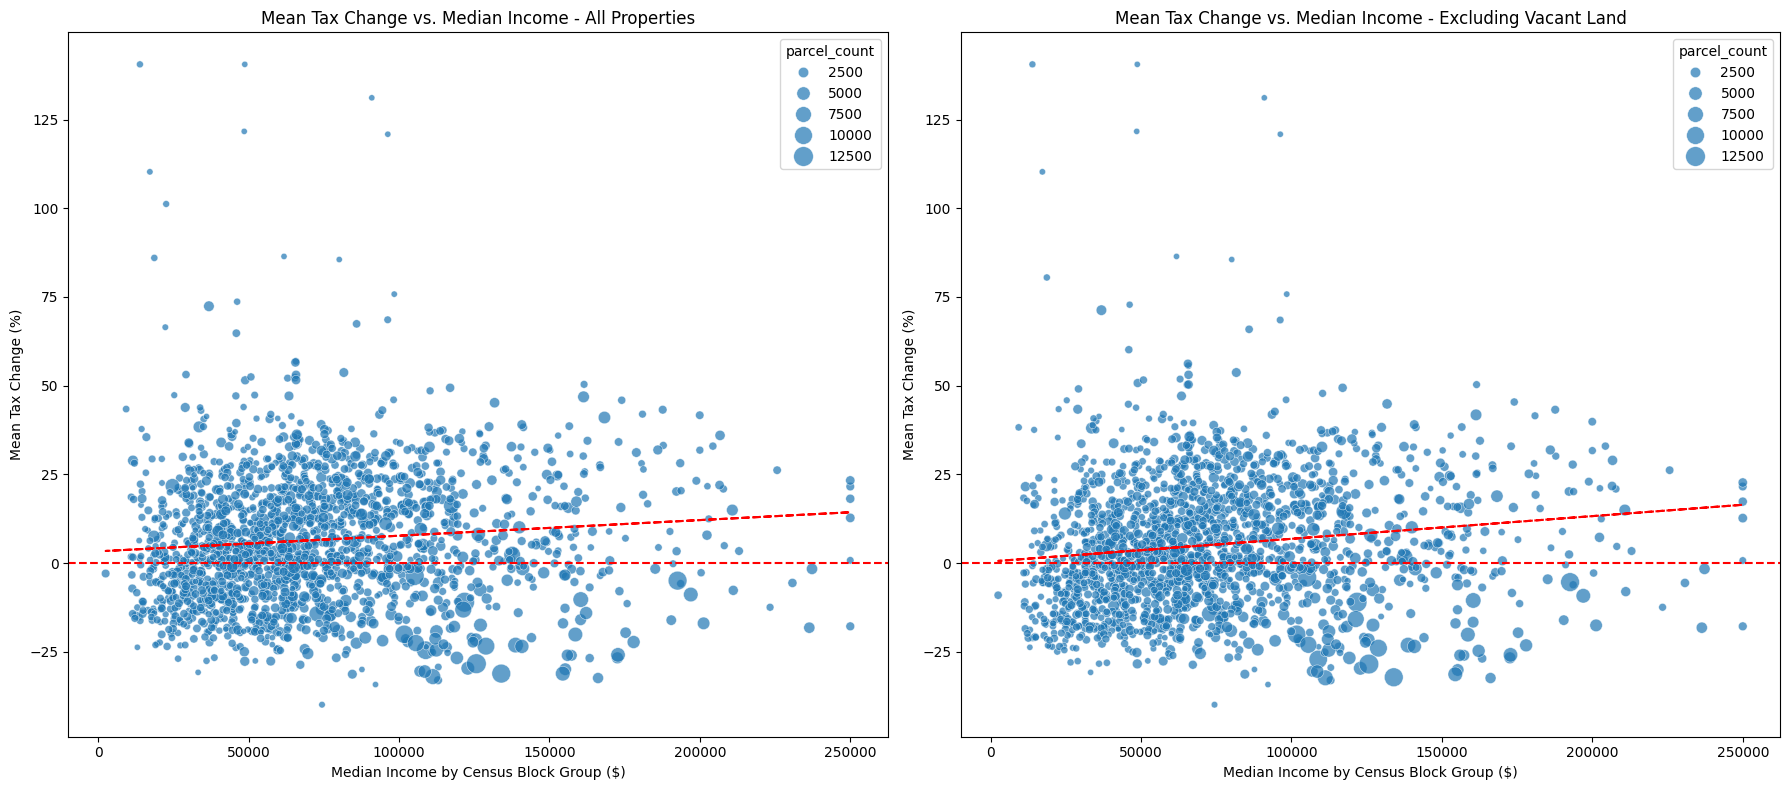

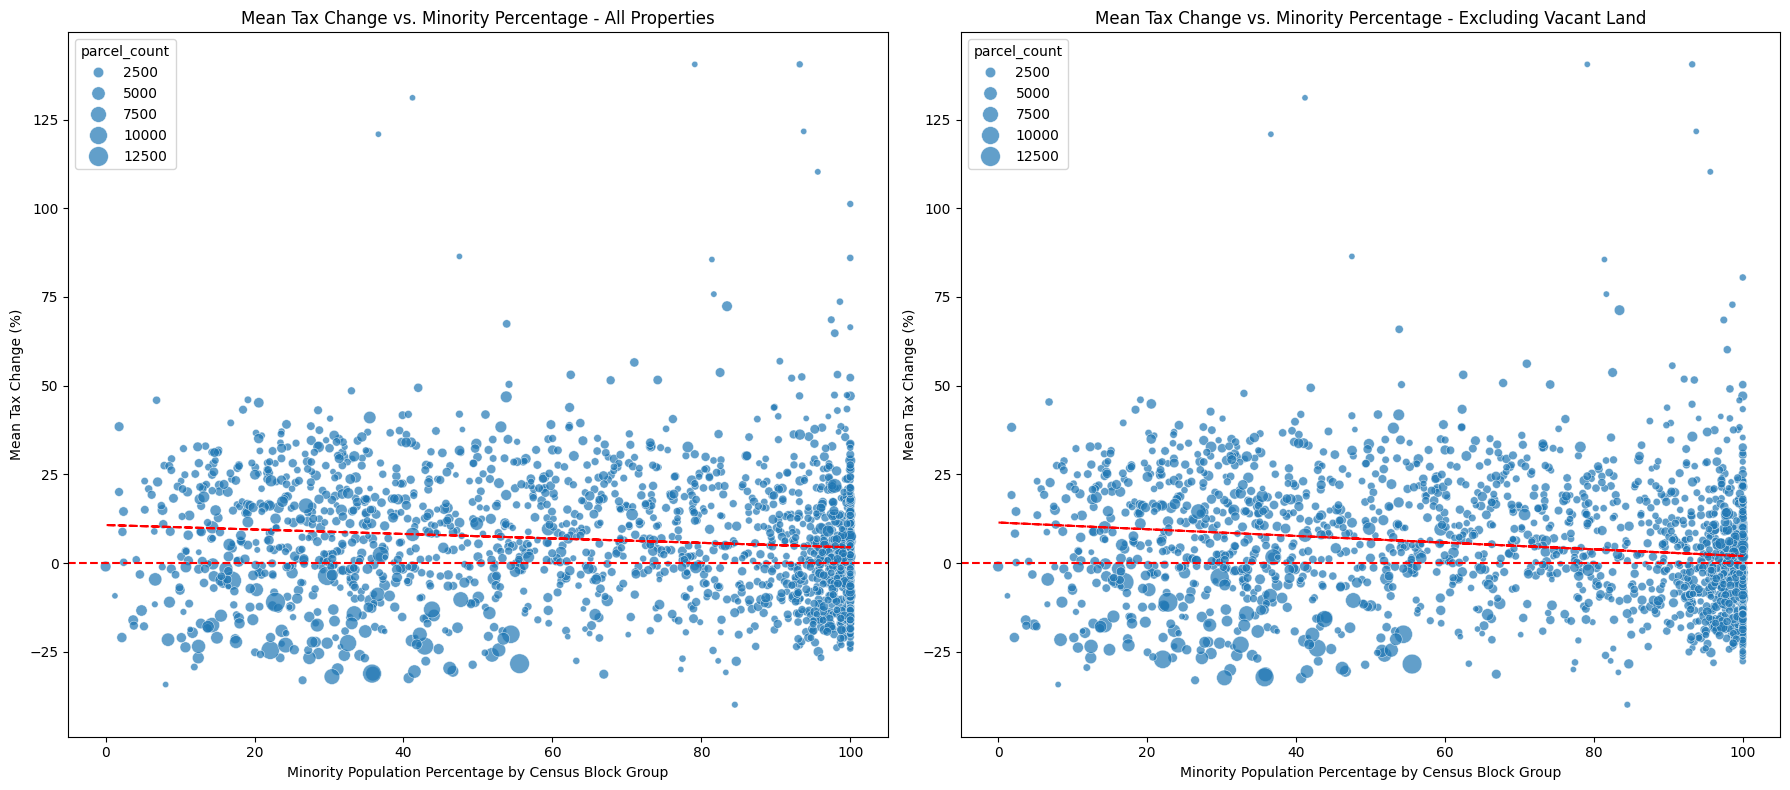

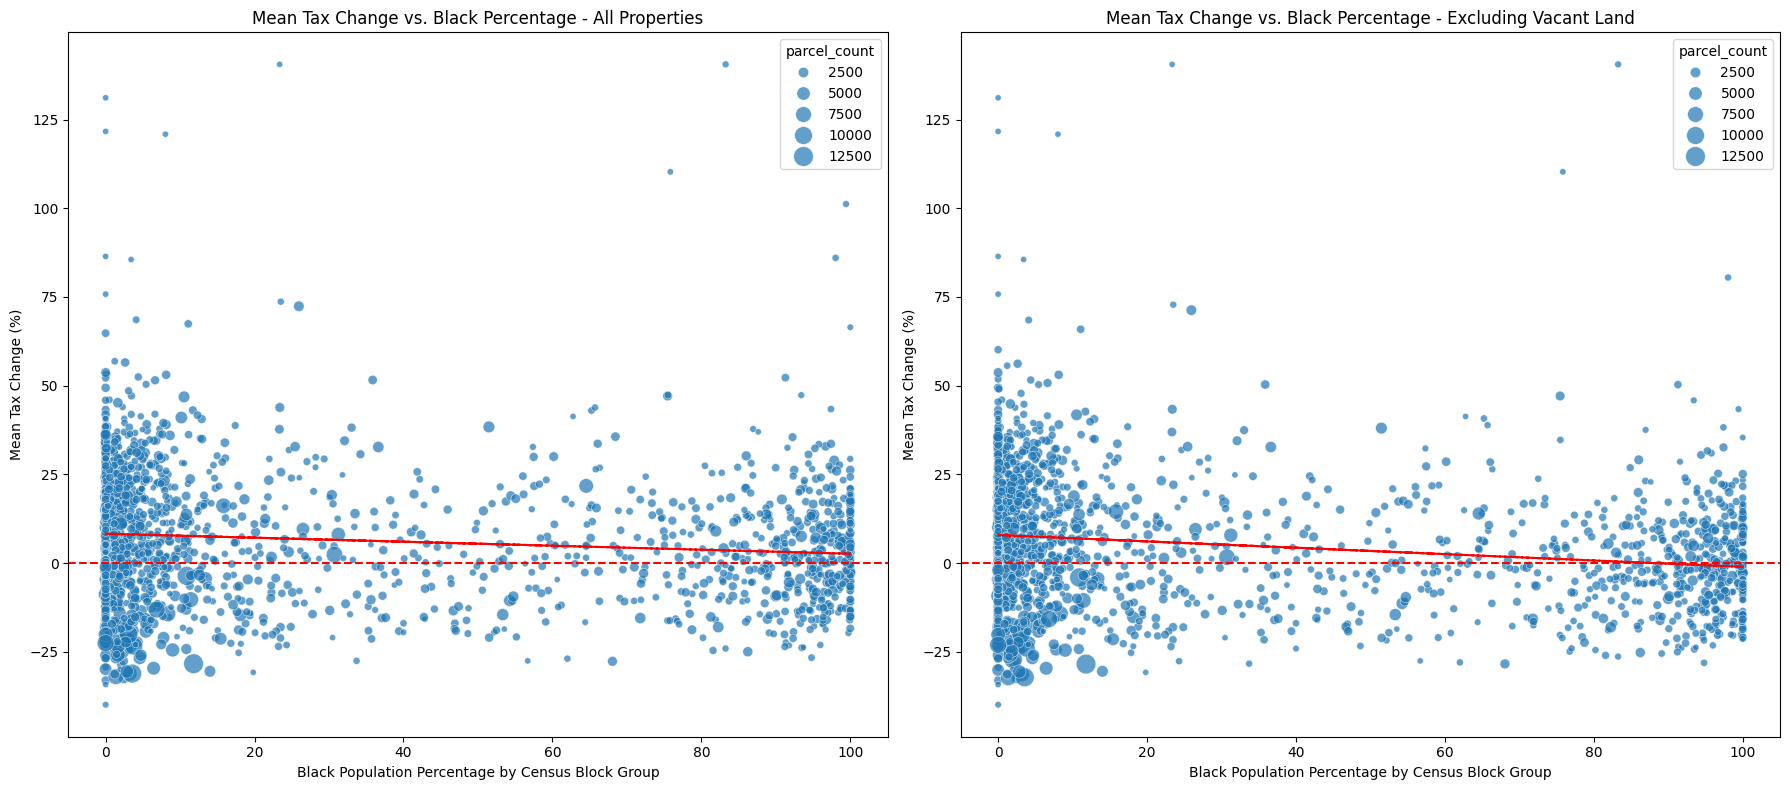

Correlation income_mean_all: 0.0980
Correlation income_median_all: 0.0729
Correlation minority_mean_all: -0.1037
Correlation black_mean_all: -0.1176
Correlation income_mean_non_vacant: 0.1428
Correlation income_median_non_vacant: 0.1054
Correlation minority_mean_non_vacant: -0.1565
Correlation black_mean_non_vacant: -0.1878


/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_36606/3966806232.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quintile_ranges = df_copy.groupby(f'{group_col}_quintile')[group_col].agg(['min', 'max']).reset_index()
/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_36606/3966806232.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_copy.groupby(f'{group_col}_quintile').agg(
/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_36606/3966806232.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of panda


Tax impact by income quintile (all properties):


,median_income_quintile,count,mean_tax_change,median_tax_change,mean_value,range
0,Q1 (Lowest),514698,8.736924,0.000000,32697.617323,2499.0 - 45750.0
1,Q2,514139,11.654621,-0.920761,56910.492556,45774.0 - 65774.0
2,Q3,515263,17.001343,0.000000,75944.873519,65781.0 - 87500.0
3,Q4,514368,-10.278964,-1.955709,102746.187234,87520.0 - 118086.0
4,Q5 (Highest),513309,-34.947623,-4.926860,152114.080567,118190.0 - 250001.0



Tax impact by income quintile (excluding vacant land):


,median_income_quintile,count,mean_tax_change,median_tax_change,mean_value,range
0,Q1 (Lowest),499450,7.134701,-0.930373,33771.713261,2499.0 - 47222.0
1,Q2,499756,14.576772,-1.152510,58135.069548,47237.0 - 66550.0
2,Q3,498068,10.872887,-0.197731,77035.361447,66625.0 - 88291.0
3,Q4,499328,-12.747977,-2.377853,103721.566628,88333.0 - 118500.0
4,Q5 (Highest),498745,-38.264886,-5.004119,152827.966053,118621.0 - 250001.0



Tax impact by minority percentage quintile (all properties):


,minority_pct_quintile,count,mean_tax_change,median_tax_change,mean_value,range
0,Q1 (Lowest),515576,2.299711,-2.983757,17.608689,0.0 - 27.7
1,Q2,513307,-22.152689,-3.998498,35.622427,27.7 - 45.2
2,Q3,515131,-7.003616,0.000000,58.375405,45.4 - 73.4
3,Q4,515592,14.785628,-1.692509,88.285000,73.5 - 97.3
4,Q5 (Highest),512171,4.281615,0.000000,99.441260,97.4 - 100.0



Tax impact by minority percentage quintile (excluding vacant land):


,minority_pct_quintile,count,mean_tax_change,median_tax_change,mean_value,range
0,Q1 (Lowest),500402,0.374878,-3.328063,17.358028,0.0 - 27.4
1,Q2,505798,-25.069031,-3.998498,35.128073,27.4 - 43.8
2,Q3,491882,-10.199868,-0.501763,56.936241,44.1 - 71.1
3,Q4,500920,14.349657,-2.459101,86.580050,71.1 - 96.9
4,Q5 (Highest),496345,2.287174,-0.107903,99.315451,96.9 - 100.0


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def filter_data(df):
    """Filter data to remove negative median incomes and create non-vacant subset"""
    df_filtered = df[df['median_income'] > 0].copy()
    non_vacant_df = df[(df['major_class_description'] != 'Vacant') & (df['median_income'] > 0)].copy()
    return df_filtered, non_vacant_df

def calculate_block_group_summary(df):
    """Calculate summary statistics for census block groups"""
    summary = df.groupby('std_geoid').agg(
        median_income=('median_income', 'first'),
        minority_pct=('minority_pct', 'first'),
        black_pct=('black_pct', 'first'),
        total_current_tax=('current_tax', 'sum'),
        total_new_tax=('new_tax', 'sum'),
        mean_tax_change=('tax_change', 'mean'),
        median_tax_change=('tax_change', 'median'),
        median_tax_change_pct=('tax_change_pct', 'median'),
        parcel_count=('tax_change', 'count'),
        has_vacant_land=('major_class_description', lambda x: 'Vacant' in x.values)
    ).reset_index()
    
    summary['mean_tax_change_pct'] = ((summary['total_new_tax'] - summary['total_current_tax']) / 
                                    summary['total_current_tax']) * 100
    return summary

def create_scatter_plot(data, x_col, y_col, ax, title, xlabel, ylabel):
    """Create a scatter plot with trend line"""
    sns.scatterplot(
        data=data,
        x=x_col,
        y=y_col,
        size='parcel_count',
        sizes=(20, 200),
        alpha=0.7,
        ax=ax
    )
    
    ax.axhline(y=0, color='r', linestyle='--')
    
    x = data[x_col].dropna()
    y = data[y_col].dropna()
    mask = ~np.isnan(x) & ~np.isnan(y)
    
    if len(x[mask]) > 1:
        z = np.polyfit(x[mask], y[mask], 1)
        p = np.poly1d(z)
        ax.plot(x[mask], p(x[mask]), "r--")
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

def plot_comparison(data1, data2, x_col, y_col, title_prefix, xlabel):
    """Create side-by-side comparison plots"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    create_scatter_plot(data1, x_col, y_col, ax1, 
                       f'{title_prefix} - All Properties', xlabel, 'Mean Tax Change (%)')
    create_scatter_plot(data2, x_col, y_col, ax2,
                       f'{title_prefix} - Excluding Vacant Land', xlabel, 'Mean Tax Change (%)')
    
    plt.tight_layout()
    plt.show()

def calculate_correlations(data1, data2):
    """Calculate correlations between variables"""
    correlations = {}
    for df, suffix in [(data1, 'all'), (data2, 'non_vacant')]:
        correlations[f'income_mean_{suffix}'] = df[['median_income', 'mean_tax_change_pct']].corr().iloc[0, 1]
        correlations[f'income_median_{suffix}'] = df[['median_income', 'median_tax_change_pct']].corr().iloc[0, 1]
        correlations[f'minority_mean_{suffix}'] = df[['minority_pct', 'mean_tax_change_pct']].corr().iloc[0, 1]
        correlations[f'black_mean_{suffix}'] = df[['black_pct', 'mean_tax_change_pct']].corr().iloc[0, 1]
    return correlations

def create_quintile_summary(df, group_col, value_col):
    """Create summary statistics by quintiles"""
    # Create a copy to avoid modifying the original dataframe
    df_copy = df.copy()
    df_copy[f'{group_col}_quintile'] = pd.qcut(df_copy[group_col], 5, 
                                         labels=["Q1 (Lowest)", "Q2", "Q3", "Q4", "Q5 (Highest)"])
    
    # Get the range for each quintile
    quintile_ranges = df_copy.groupby(f'{group_col}_quintile')[group_col].agg(['min', 'max']).reset_index()
    quintile_ranges['range'] = quintile_ranges.apply(lambda x: f"{x['min']:.1f} - {x['max']:.1f}", axis=1)
    
    summary = df_copy.groupby(f'{group_col}_quintile').agg(
        count=('tax_change', 'count'),
        mean_tax_change=('tax_change', 'mean'),
        median_tax_change=('tax_change', 'median'),
        mean_value=(value_col, 'mean')
    ).reset_index()
    
    # Merge the range information - fix the column reference
    summary = summary.merge(quintile_ranges[['range']], 
                           left_index=True, 
                           right_index=True, 
                           how='left')
    
    return summary

# Main execution
gdf_filtered, non_vacant_gdf = filter_data(df)
print(f"Number of rows in gdf_filtered: {len(gdf_filtered)}")
print(f"Number of rows in non_vacant_gdf: {len(non_vacant_gdf)}")

# Calculate block group summaries
census_block_groups = calculate_block_group_summary(gdf_filtered)
non_vacant_block_summary = calculate_block_group_summary(non_vacant_gdf)

# Create comparison plots
plot_comparison(census_block_groups, non_vacant_block_summary, 
               'median_income', 'mean_tax_change_pct', 
               'Mean Tax Change vs. Median Income', 
               'Median Income by Census Block Group ($)')

plot_comparison(census_block_groups, non_vacant_block_summary,
               'minority_pct', 'mean_tax_change_pct',
               'Mean Tax Change vs. Minority Percentage',
               'Minority Population Percentage by Census Block Group')

plot_comparison(census_block_groups, non_vacant_block_summary,
               'black_pct', 'mean_tax_change_pct',
               'Mean Tax Change vs. Black Percentage',
               'Black Population Percentage by Census Block Group')

# Calculate and print correlations
correlations = calculate_correlations(census_block_groups, non_vacant_block_summary)
for key, value in correlations.items():
    print(f"Correlation {key}: {value:.4f}")

# Create and display quintile summaries
income_quintile_summary = create_quintile_summary(gdf_filtered, 'median_income', 'median_income')
non_vacant_income_quintile_summary = create_quintile_summary(non_vacant_gdf, 'median_income', 'median_income')
minority_quintile_summary = create_quintile_summary(gdf_filtered, 'minority_pct', 'minority_pct')
non_vacant_minority_quintile_summary = create_quintile_summary(non_vacant_gdf, 'minority_pct', 'minority_pct')

print("\nTax impact by income quintile (all properties):")
display(income_quintile_summary)
print("\nTax impact by income quintile (excluding vacant land):")
display(non_vacant_income_quintile_summary)
print("\nTax impact by minority percentage quintile (all properties):")
display(minority_quintile_summary)
print("\nTax impact by minority percentage quintile (excluding vacant land):")
display(non_vacant_minority_quintile_summary)
